# Task 2-1: Fashion-MNIST Classification

Comparing single-layer NN vs MLP on Fashion-MNIST.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [2]:
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
print(f'Train: {len(train_data)}, Test: {len(test_data)}')

Train: 60000, Test: 10000


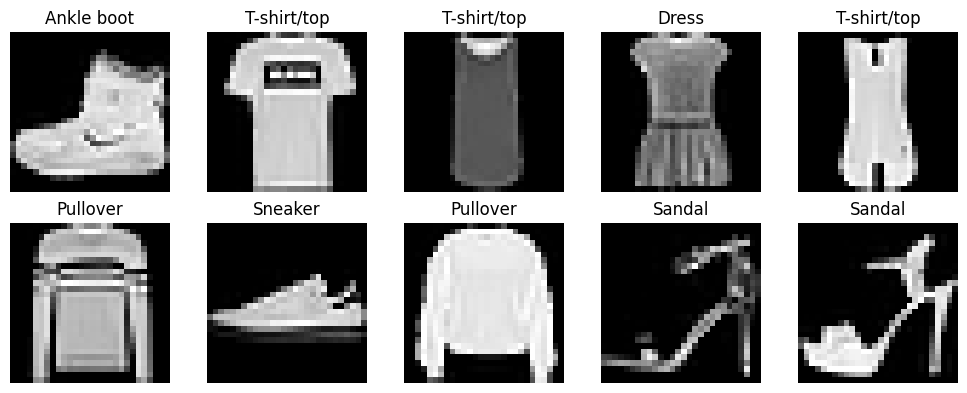

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, lbl = train_data[i]
    ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
    ax.set_title(CLASS_NAMES[lbl])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
class SingleLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784, 10)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

class MLP2(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, hidden), nn.ReLU(), nn.Linear(hidden, 10))
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

class MLP3(nn.Module):
    def __init__(self, h1=512, h2=256, drop=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, h1), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(h2, 10)
        )
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

In [5]:
def train_epoch(model, loader, criterion, opt):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        opt.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        opt.step()
        loss_sum += loss.item() * X.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return loss_sum/total, 100*correct/total

def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss_sum += criterion(out, y).item() * X.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum/total, 100*correct/total

def train_model(model, epochs=15):
    criterion = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=0.001)
    hist = {'tr_loss':[], 'tr_acc':[], 'te_loss':[], 'te_acc':[]}
    for ep in range(epochs):
        tr_l, tr_a = train_epoch(model, train_loader, criterion, opt)
        te_l, te_a = evaluate(model, test_loader, criterion)
        hist['tr_loss'].append(tr_l); hist['tr_acc'].append(tr_a)
        hist['te_loss'].append(te_l); hist['te_acc'].append(te_a)
        print(f'Ep {ep+1:2d} | Train: {tr_l:.4f}, {tr_a:.1f}% | Test: {te_l:.4f}, {te_a:.1f}%')
    return hist

In [6]:
results = []
histories = {}

In [7]:
print('--- Single Layer ---')
m1 = SingleLayer().to(device)
h1 = train_model(m1)
histories['Single'] = h1
results.append({'Model': 'Single Layer', 'Test Acc': h1['te_acc'][-1]})

--- Single Layer ---
Ep  1 | Train: 0.5586, 80.7% | Test: 0.4880, 82.8%
Ep  2 | Train: 0.4535, 84.2% | Test: 0.5079, 81.6%
Ep  3 | Train: 0.4349, 84.9% | Test: 0.4677, 83.2%
Ep  4 | Train: 0.4236, 85.2% | Test: 0.4668, 83.0%
Ep  5 | Train: 0.4163, 85.5% | Test: 0.4552, 83.9%
Ep  6 | Train: 0.4125, 85.5% | Test: 0.4479, 84.3%
Ep  7 | Train: 0.4088, 85.7% | Test: 0.4681, 83.4%
Ep  8 | Train: 0.4054, 85.8% | Test: 0.4478, 83.9%
Ep  9 | Train: 0.4019, 85.8% | Test: 0.4587, 83.4%
Ep 10 | Train: 0.4002, 86.0% | Test: 0.4564, 83.8%
Ep 11 | Train: 0.3972, 86.1% | Test: 0.4432, 84.2%
Ep 12 | Train: 0.3947, 86.1% | Test: 0.4636, 83.7%
Ep 13 | Train: 0.3952, 86.0% | Test: 0.4529, 84.1%
Ep 14 | Train: 0.3920, 86.3% | Test: 0.4663, 83.5%
Ep 15 | Train: 0.3904, 86.3% | Test: 0.4524, 83.9%


In [8]:
print('--- MLP (256) ---')
m2 = MLP2(256).to(device)
h2 = train_model(m2)
histories['MLP-256'] = h2
results.append({'Model': 'MLP (256)', 'Test Acc': h2['te_acc'][-1]})

--- MLP (256) ---
Ep  1 | Train: 0.4848, 82.4% | Test: 0.4068, 85.2%
Ep  2 | Train: 0.3714, 86.3% | Test: 0.3946, 85.5%
Ep  3 | Train: 0.3331, 87.8% | Test: 0.4014, 85.5%
Ep  4 | Train: 0.3095, 88.6% | Test: 0.3600, 87.3%
Ep  5 | Train: 0.2863, 89.4% | Test: 0.3430, 87.7%
Ep  6 | Train: 0.2709, 89.9% | Test: 0.3504, 87.4%
Ep  7 | Train: 0.2590, 90.4% | Test: 0.3629, 87.2%
Ep  8 | Train: 0.2457, 90.9% | Test: 0.3492, 87.9%
Ep  9 | Train: 0.2349, 91.2% | Test: 0.3454, 88.3%
Ep 10 | Train: 0.2255, 91.6% | Test: 0.3550, 88.0%
Ep 11 | Train: 0.2153, 91.8% | Test: 0.3499, 88.5%
Ep 12 | Train: 0.2071, 92.3% | Test: 0.3471, 88.7%
Ep 13 | Train: 0.2008, 92.4% | Test: 0.3602, 88.6%
Ep 14 | Train: 0.1939, 92.7% | Test: 0.3473, 88.7%
Ep 15 | Train: 0.1882, 92.9% | Test: 0.3571, 88.4%


In [9]:
print('--- MLP (512) ---')
m3 = MLP2(512).to(device)
h3 = train_model(m3)
histories['MLP-512'] = h3
results.append({'Model': 'MLP (512)', 'Test Acc': h3['te_acc'][-1]})

--- MLP (512) ---
Ep  1 | Train: 0.4809, 82.6% | Test: 0.4203, 85.0%
Ep  2 | Train: 0.3673, 86.5% | Test: 0.3915, 86.1%
Ep  3 | Train: 0.3277, 88.0% | Test: 0.3844, 86.2%
Ep  4 | Train: 0.3062, 88.8% | Test: 0.3531, 87.5%
Ep  5 | Train: 0.2854, 89.5% | Test: 0.3652, 86.5%
Ep  6 | Train: 0.2676, 90.1% | Test: 0.3539, 87.5%
Ep  7 | Train: 0.2541, 90.6% | Test: 0.3442, 88.0%
Ep  8 | Train: 0.2427, 90.9% | Test: 0.3473, 88.0%
Ep  9 | Train: 0.2296, 91.3% | Test: 0.3498, 88.2%
Ep 10 | Train: 0.2229, 91.6% | Test: 0.3300, 88.9%
Ep 11 | Train: 0.2098, 92.0% | Test: 0.3455, 88.2%
Ep 12 | Train: 0.2014, 92.4% | Test: 0.3411, 88.7%
Ep 13 | Train: 0.1946, 92.6% | Test: 0.3405, 89.0%
Ep 14 | Train: 0.1862, 92.9% | Test: 0.3608, 88.3%
Ep 15 | Train: 0.1802, 93.3% | Test: 0.3526, 89.0%


In [10]:
print('--- MLP 3-Layer ---')
m4 = MLP3(512, 256).to(device)
h4 = train_model(m4)
histories['MLP-3L'] = h4
results.append({'Model': 'MLP 3-Layer', 'Test Acc': h4['te_acc'][-1]})

--- MLP 3-Layer ---
Ep  1 | Train: 0.4844, 82.3% | Test: 0.4484, 83.8%
Ep  2 | Train: 0.3636, 86.7% | Test: 0.4063, 84.8%
Ep  3 | Train: 0.3269, 88.0% | Test: 0.3636, 87.1%
Ep  4 | Train: 0.2999, 88.8% | Test: 0.3767, 86.4%
Ep  5 | Train: 0.2801, 89.6% | Test: 0.3492, 87.6%
Ep  6 | Train: 0.2631, 90.2% | Test: 0.3667, 87.0%
Ep  7 | Train: 0.2478, 90.6% | Test: 0.3413, 88.0%
Ep  8 | Train: 0.2343, 91.1% | Test: 0.3442, 88.1%
Ep  9 | Train: 0.2219, 91.6% | Test: 0.3339, 88.3%
Ep 10 | Train: 0.2087, 92.1% | Test: 0.3513, 88.7%
Ep 11 | Train: 0.1991, 92.5% | Test: 0.3469, 87.8%
Ep 12 | Train: 0.1902, 92.8% | Test: 0.3723, 88.3%
Ep 13 | Train: 0.1819, 93.1% | Test: 0.3712, 88.5%
Ep 14 | Train: 0.1725, 93.4% | Test: 0.3766, 89.3%
Ep 15 | Train: 0.1668, 93.7% | Test: 0.3609, 88.9%


In [11]:
print('--- MLP + Dropout ---')
m5 = MLP3(512, 256, drop=0.3).to(device)
h5 = train_model(m5)
histories['MLP+Drop'] = h5
results.append({'Model': 'MLP + Dropout', 'Test Acc': h5['te_acc'][-1]})

--- MLP + Dropout ---
Ep  1 | Train: 0.5425, 80.2% | Test: 0.4546, 82.9%
Ep  2 | Train: 0.4240, 84.6% | Test: 0.4097, 84.7%
Ep  3 | Train: 0.3872, 85.8% | Test: 0.3830, 85.8%
Ep  4 | Train: 0.3690, 86.6% | Test: 0.3743, 86.5%
Ep  5 | Train: 0.3542, 87.1% | Test: 0.3527, 87.2%
Ep  6 | Train: 0.3414, 87.3% | Test: 0.3518, 87.2%
Ep  7 | Train: 0.3297, 88.0% | Test: 0.3431, 87.5%
Ep  8 | Train: 0.3222, 88.1% | Test: 0.3550, 87.4%
Ep  9 | Train: 0.3143, 88.4% | Test: 0.3422, 87.4%
Ep 10 | Train: 0.3080, 88.7% | Test: 0.3284, 88.4%
Ep 11 | Train: 0.3015, 88.9% | Test: 0.3466, 88.2%
Ep 12 | Train: 0.2954, 89.0% | Test: 0.3292, 88.4%
Ep 13 | Train: 0.2856, 89.3% | Test: 0.3393, 88.2%
Ep 14 | Train: 0.2810, 89.6% | Test: 0.3304, 88.6%
Ep 15 | Train: 0.2767, 89.6% | Test: 0.3507, 88.0%


In [12]:
df = pd.DataFrame(results)
print('\n=== Results ===')
print(df.to_string(index=False))



=== Results ===
        Model  Test Acc
 Single Layer     83.87
    MLP (256)     88.42
    MLP (512)     88.97
  MLP 3-Layer     88.94
MLP + Dropout     88.00


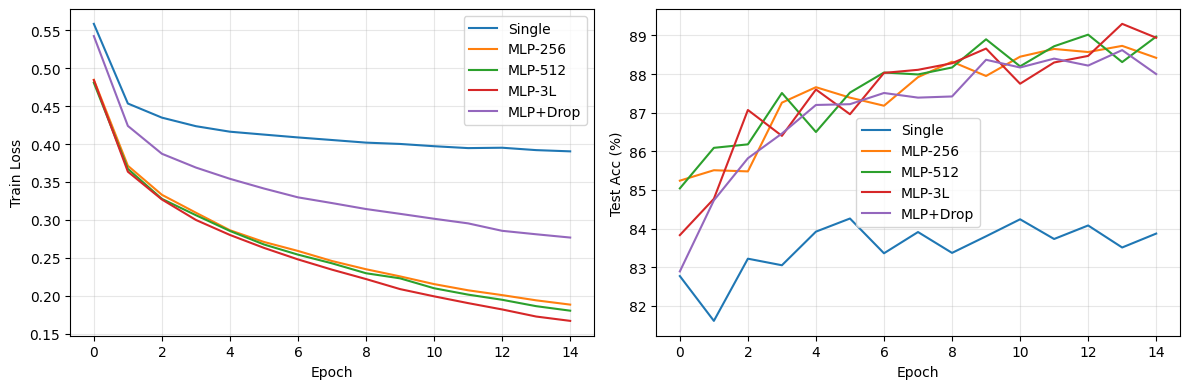

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h in histories.items():
    axes[0].plot(h['tr_loss'], label=name)
    axes[1].plot(h['te_acc'], label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Acc (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

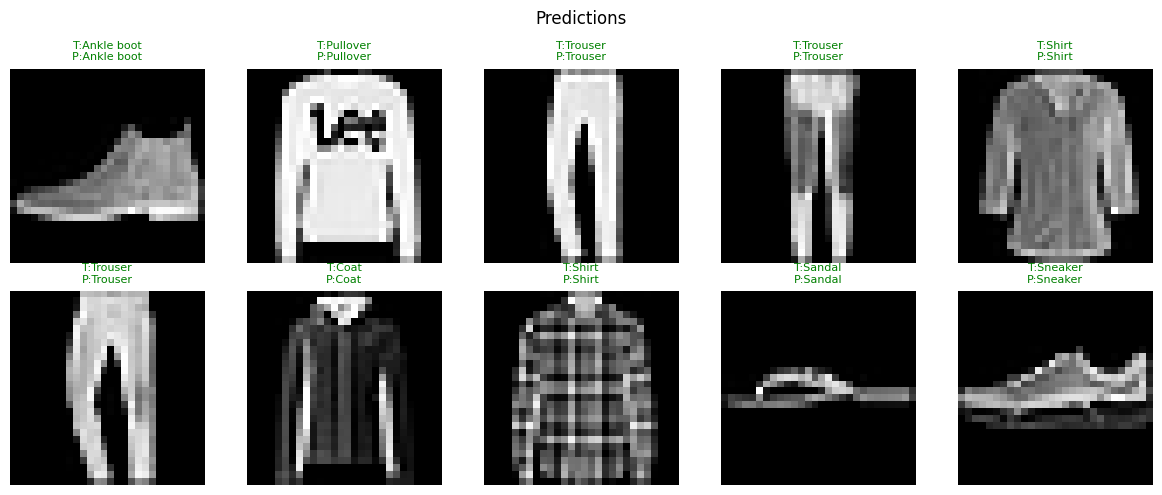

In [14]:
best = m4
best.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, lbl = test_data[i]
    with torch.no_grad():
        pred = best(img.unsqueeze(0).to(device)).argmax(1).item()
    ax.imshow(img.squeeze() * 0.5 + 0.5, cmap='gray')
    color = 'green' if pred == lbl else 'red'
    ax.set_title(f'T:{CLASS_NAMES[lbl]}\nP:{CLASS_NAMES[pred]}', fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('Predictions')
plt.tight_layout()
plt.show()

## Summary

- Single layer: ~84%
- MLP with hidden layers: ~88-89%
- Deeper networks and dropout help